# Project 3: Customer Segmentation (Unsupervised Learning)



## Import libraries and load the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset for Data Analytics.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Explore the data


In [ ]:
print("Orders:", len(df))
print("Unique customers:", df["CustomerID"].nunique())

Orders: 1200
Unique customers: 1189


In [ ]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

## Clean the data and create behaviour features



In [ ]:
df["CouponCode"] = df["CouponCode"].fillna("NONE")   
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek

df["UsedCoupon"] = (df["CouponCode"] != "NONE").astype(int)
df["CartConversion"] = df["Quantity"] / df["ItemsInCart"]

df[["Quantity", "TotalPrice", "ItemsInCart", "UsedCoupon", "CartConversion"]].describe().round(2)

,Quantity,TotalPrice,ItemsInCart,UsedCoupon,CartConversion
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.95,1053.97,5.48,0.74,0.58
std,1.41,819.86,2.28,0.44,0.25
min,1.00,11.39,1.00,0.00,0.17
25%,2.00,410.52,4.00,0.00,0.40
50%,3.00,823.62,5.00,1.00,0.50
75%,4.00,1578.48,7.00,1.00,0.75
max,5.00,3456.40,10.00,1.00,1.00


## Encode and scale


In [ ]:
drop_cols = ["OrderID", "CustomerID", "ShippingAddress", "TrackingNumber", "Date"]
X = df.drop(columns=drop_cols)
X = pd.get_dummies(X, columns=["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"])

print("Number of columns after encoding:", X.shape[1])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Number of columns after encoding: 34


## Reduce dimensions with PCA


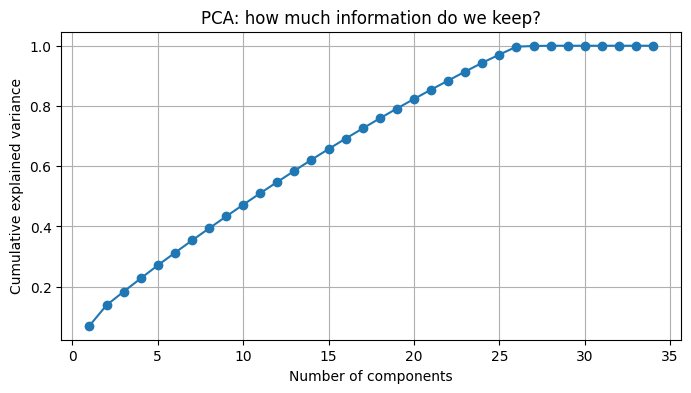

In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: how much information do we keep?")
plt.grid(True)
plt.show()

In [ ]:
# Reduce to 3 dimensions
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))

Shape after PCA: (1200, 3)
Variance explained by each component: [0.07  0.068 0.045]


In [ ]:

loadings = pd.DataFrame(pca.components_[:2].T, index=X.columns, columns=["PC1", "PC2"])

print("Top features driving PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print()
print("Top features driving PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

Top features driving PC1:
UsedCoupon             0.631463
CouponCode_NONE        0.631463
CouponCode_FREESHIP    0.227230
CouponCode_WINTER15    0.208083
CouponCode_SAVE10      0.204312
Name: PC1, dtype: float64

Top features driving PC2:
TotalPrice        0.592691
Quantity          0.534360
ItemsInCart       0.407640
UnitPrice         0.336096
CartConversion    0.135285
Name: PC2, dtype: float64


## How many clusters? Elbow Method + Silhouette Score


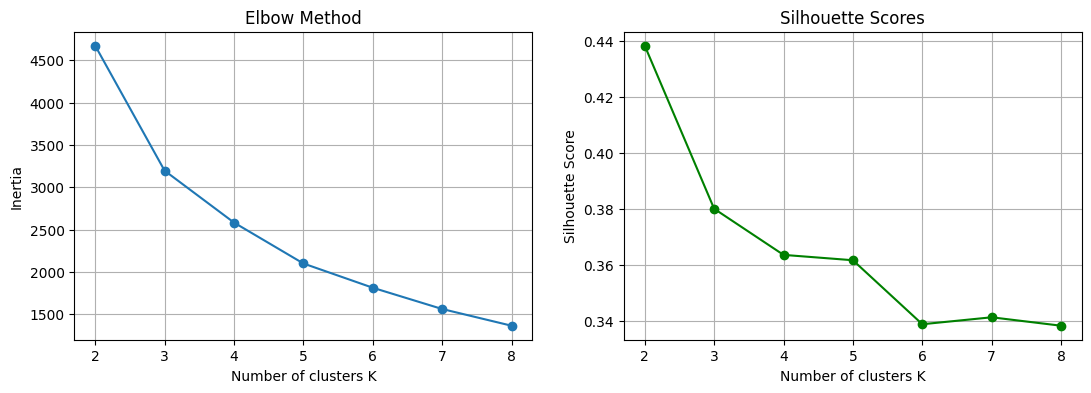

K=2:  inertia=4672  silhouette=0.438
K=3:  inertia=3196  silhouette=0.380
K=4:  inertia=2582  silhouette=0.364
K=5:  inertia=2099  silhouette=0.362
K=6:  inertia=1812  silhouette=0.339
K=7:  inertia=1561  silhouette=0.341
K=8:  inertia=1363  silhouette=0.338


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, marker="o", color="green")
axes[1].set_xlabel("Number of clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")
axes[1].grid(True)
plt.show()

for k, i, s in zip(K_range, inertias, silhouettes):
    print(f"K={k}:  inertia={i:.0f}  silhouette={s:.3f}")

## Run the final K-Means and visualise

In [ ]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_pca)

df["Cluster"].value_counts().sort_index()

Cluster
0    408
1    309
2    483
Name: count, dtype: int64

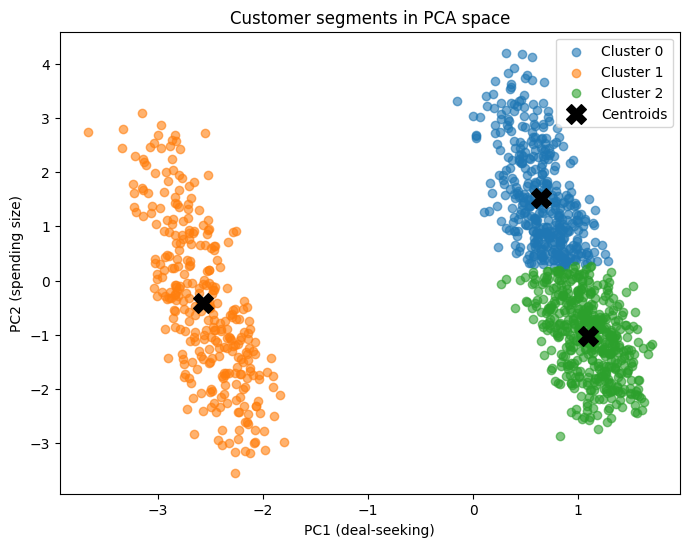

In [ ]:
# 2D view: PC1 vs PC2
plt.figure(figsize=(8, 6))
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="black", marker="X", s=200, label="Centroids")
plt.xlabel("PC1 (deal-seeking)")
plt.ylabel("PC2 (spending size)")
plt.title("Customer segments in PCA space")
plt.legend()
plt.show()

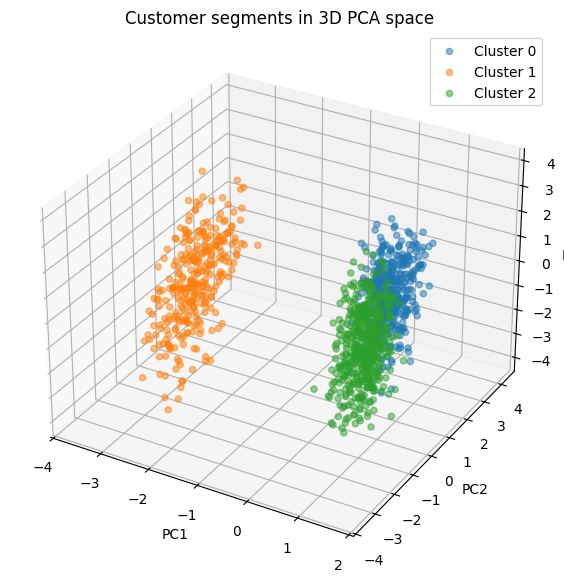

In [ ]:
# 3D view 
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2], label=f"Cluster {c}", alpha=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Customer segments in 3D PCA space")
ax.legend()
plt.show()

## Profile the clusters


In [ ]:
profile = df.groupby("Cluster")[["TotalPrice", "Quantity", "UnitPrice",
                                 "ItemsInCart", "CartConversion", "UsedCoupon"]].mean().round(2)
profile["Customers"] = df.groupby("Cluster").size()
profile

,TotalPrice,Quantity,UnitPrice,ItemsInCart,CartConversion,UsedCoupon,Customers
Cluster,,,,,,,
0,1732.49,4.05,441.50,6.82,0.63,1.0,408
1,1043.37,3.05,344.35,5.56,0.59,0.0,309
2,487.59,1.95,292.25,4.31,0.53,1.0,483


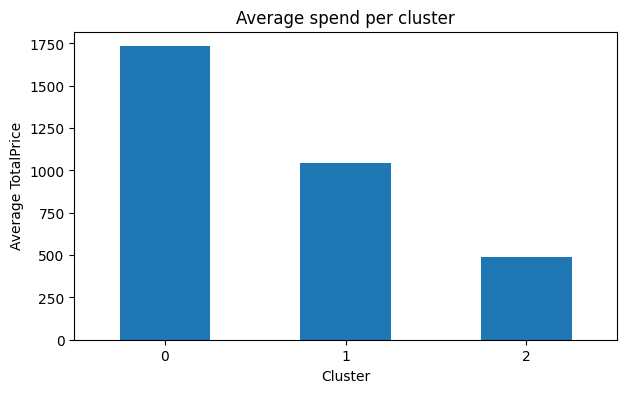

In [ ]:

profile[["TotalPrice"]].plot(kind="bar", figsize=(7, 4), legend=False,
                             title="Average spend per cluster", color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Average TotalPrice")
plt.xticks(rotation=0)
plt.show()